# 01_Data_discovery

Source des données : [Bases de données annuelles des accidents corporels de la circulation routière - Années de 2005 à 2024](https://www.data.gouv.fr/datasets/bases-de-donnees-annuelles-des-accidents-corporels-de-la-circulation-routiere-annees-de-2005-a-2024)

## Import des librairies et des données

In [1]:
import pandas as pd
from pathlib import Path
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
# Chemin vers le dossier raw
data_raw_path = Path("../data/raw")

# Dictionnaire pour stocker tous les DataFrames
dataframes = {}

# Boucle sur tous les fichiers CSV dans tous les sous-dossiers
for csv_file in data_raw_path.rglob("*.csv"):
    
    # Récupère le nom du fichier sans extension
    file_stem = csv_file.stem
    
    # Crée un nom unique pour le DataFrame
    df_name = f"{file_stem}"
    
    # Lecture du CSV en string pour la découverte
    df = pd.read_csv(csv_file, sep=";", dtype=str)
    
    # Stocke le DataFrame dans le dictionnaire
    dataframes[df_name] = df

# Affichage pour vérifier que tout est importé
print("DataFrames importés :", list(dataframes.keys()))

DataFrames importés : ['caract-2022', 'lieux-2022', 'usagers-2022', 'caract-2023', 'lieux-2023', 'usagers-2023', 'caract-2024', 'lieux-2024', 'usagers-2024']


## Description des données utilisées

Nous utiliserons 3 fichiers, sur une période de 3 ans (2022-2024) :
- caractéristiques
- lieux
- usagers

### Lecture de la doc

BDD répertorie l'intégralité des accidents corporels de la circulation, intervenus durant une année précise en France métropolitaine, dans les départements d'Outre-mer et dans les autres territoires d'outre-mer. 

#### Spécifications de la base

BDD composées de 4 fichiers au format csv :

- Caractéristiques : décrit les circonstances générales de l'accident
- Lieux : décrit le lieu principal de l'accident même si celui-ci s'est déroulé à une intersection
- Véhicules : véhicules impliqués
- Usagers : usagers impliqués

A partir de 2021, ajout des usagers en fuite, ce qui entraîne des manques d'informations sur ces derniers (notamment sexe, âge, gravité des blessures).

→ Le n° d'identifiant de l’accident (Cf. "Num_Acc") présent dans ces 4 rubriques permet d'établir un lien entre toutes les variables qui décrivent un accident.

→ Quand un accident comporte plusieurs véhicules, il faut aussi pouvoir relier chaque véhicule à ses occupants. Ce lien est fait par la variable `id_vehicule`.

Quand les variables contiennent des cellules vides, un zéro ou un point : dans les 3 cas, ce sont des cellules non renseignées par les forces de l'ordre, ou sans objet.

**Géolocalisation de l'accident**

- adresse partielle non normalisée (champ adr)
- coordonnées gps (projection WGS84)
- numéro de la route, PR de rattachement et distance curviligne à ce PR

→ Attention : accidents pas toujours géoloc précisément. A minima : commune de l'accident.

**Véhicule en fuite**  
Si un véhicule a un `id` dans la table `vehicule`, mais qu'il n'est pas dans `usagers` : alors conducteur en fuite non créé dans la base.

2024 : 24 conducteurs en fuite mais pas créés dans la base → donc 24 `id_vehicule` de la table `vehicule` qui ne sont pas dans la table `usager`

Sachant qu’il y a en réalité bien plus de conducteurs en fuite non retrouvés dans la base, dont l’âge et le sexe ne sont pas connus.

#### Détail des variables : voir doc

## Exploration rapide des données

In [3]:
for name, df in dataframes.items():
    print("*" * 80)
    print("=" * 80)
    print(f"DATAFRAME : {name}")
    print("=" * 80)
    # Head
    display(df.head())
    # Shape
    print("Shape :", df.shape)
    # Info
    print("\nInfo :")
    df.info()
    # Describe
    print("\nDescribe :")
    display(df.describe())
    # %age de valeurs manquantes
    missing_percent = df.isna().mean() * 100
    print("\nPourcentage de valeurs manquantes par colonne :")
    print(missing_percent.sort_values(ascending=False))

********************************************************************************
DATAFRAME : caract-2022


,Accident_Id,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"


Shape : (55302, 15)

Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55302 entries, 0 to 55301
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Accident_Id  55302 non-null  object
 1   jour         55302 non-null  object
 2   mois         55302 non-null  object
 3   an           55302 non-null  object
 4   hrmn         55302 non-null  object
 5   lum          55302 non-null  object
 6   dep          55302 non-null  object
 7   com          55302 non-null  object
 8   agg          55302 non-null  object
 9   int          55302 non-null  object
 10  atm          55302 non-null  object
 11  col          55302 non-null  object
 12  adr          54069 non-null  object
 13  lat          55302 non-null  object
 14  long         55302 non-null  object
dtypes: object(15)
memory usage: 6.3+ MB

Describe :


,Accident_Id,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
count,55302,55302,55302,55302,55302,55302,55302,55302,55302,55302,55302,55302,54069,55302,55302
unique,55302,31,12,1,1398,6,107,11253,2,10,10,8,29489,53457,53812
top,202200000001,14,06,2022,18:00,1,75,75116,2,1,1,3,A4,"48,8172046066","2,4285178250"
freq,1,1978,5418,55302,692,36845,5071,551,35036,35349,45269,16838,289,11,11



Pourcentage de valeurs manquantes par colonne :
adr            2.229576
Accident_Id    0.000000
jour           0.000000
mois           0.000000
an             0.000000
hrmn           0.000000
lum            0.000000
dep            0.000000
com            0.000000
agg            0.000000
int            0.000000
atm            0.000000
col            0.000000
lat            0.000000
long           0.000000
dtype: float64
********************************************************************************
DATAFRAME : lieux-2022


...


Pourcentage de valeurs manquantes par colonne :
lartpc     99.953024
v2         91.578408
voie       18.977053
Num_Acc     0.000000
pr1         0.000000
situ        0.000000
infra       0.000000
surf        0.000000
larrout     0.000000
plan        0.000000
pr          0.000000
catr        0.000000
prof        0.000000
vosp        0.000000
nbv         0.000000
circ        0.000000
v1          0.000000
vma         0.000000
dtype: float64
********************************************************************************
DATAFRAME : usagers-2024


,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1,1,3,1,2003,2,1,-1,-1,-1,-1,-1
1,202400000001,203 988 582,155 781 759,B01,1,1,1,1,1997,4,1,-1,-1,-1,-1,-1
2,202400000002,203 988 579,155 781 757,A01,10,3,3,2,1927,5,0,-1,-1,3,3,1
3,202400000002,203 988 580,155 781 757,A01,1,1,1,1,1987,4,1,0,-1,3,3,1
4,202400000003,203 988 574,155 781 756,A01,2,2,4,2,2007,5,8,0,-1,-1,-1,-1


Shape : (125187, 16)

Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125187 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Num_Acc      125187 non-null  object
 1   id_usager    125187 non-null  object
 2   id_vehicule  125187 non-null  object
 3   num_veh      125187 non-null  object
 4   place        125187 non-null  object
 5   catu         125187 non-null  object
 6   grav         125187 non-null  object
 7   sexe         125187 non-null  object
 8   an_nais      122608 non-null  object
 9   trajet       125187 non-null  object
 10  secu1        125187 non-null  object
 11  secu2        125187 non-null  object
 12  secu3        125187 non-null  object
 13  locp         125187 non-null  object
 14  actp         125187 non-null  object
 15  etatp        125187 non-null  object
dtypes: object(16)
memory usage: 15.3+ MB

Describe :


,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
count,125187,125187,125187,125187,125187,125187,125187,125187,122608,125187,125187,125187,125187,125187,125187,125187
unique,54402,125187,92654,45,11,3,4,3,105,8,11,11,11,11,13,4
top,202400034184,203 988 581,155 721 557,A01,1,1,1,1,2004,5,1,-1,-1,-1,-1,-1
freq,56,1,56,75443,92567,92581,52920,83864,3614,45375,72919,53813,113133,61771,61726,114932



Pourcentage de valeurs manquantes par colonne :
an_nais        2.060118
Num_Acc        0.000000
id_usager      0.000000
id_vehicule    0.000000
num_veh        0.000000
place          0.000000
catu           0.000000
grav           0.000000
sexe           0.000000
trajet         0.000000
secu1          0.000000
secu2          0.000000
secu3          0.000000
locp           0.000000
actp           0.000000
etatp          0.000000
dtype: float64


### Missingno

DATAFRAME : caract-2022


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

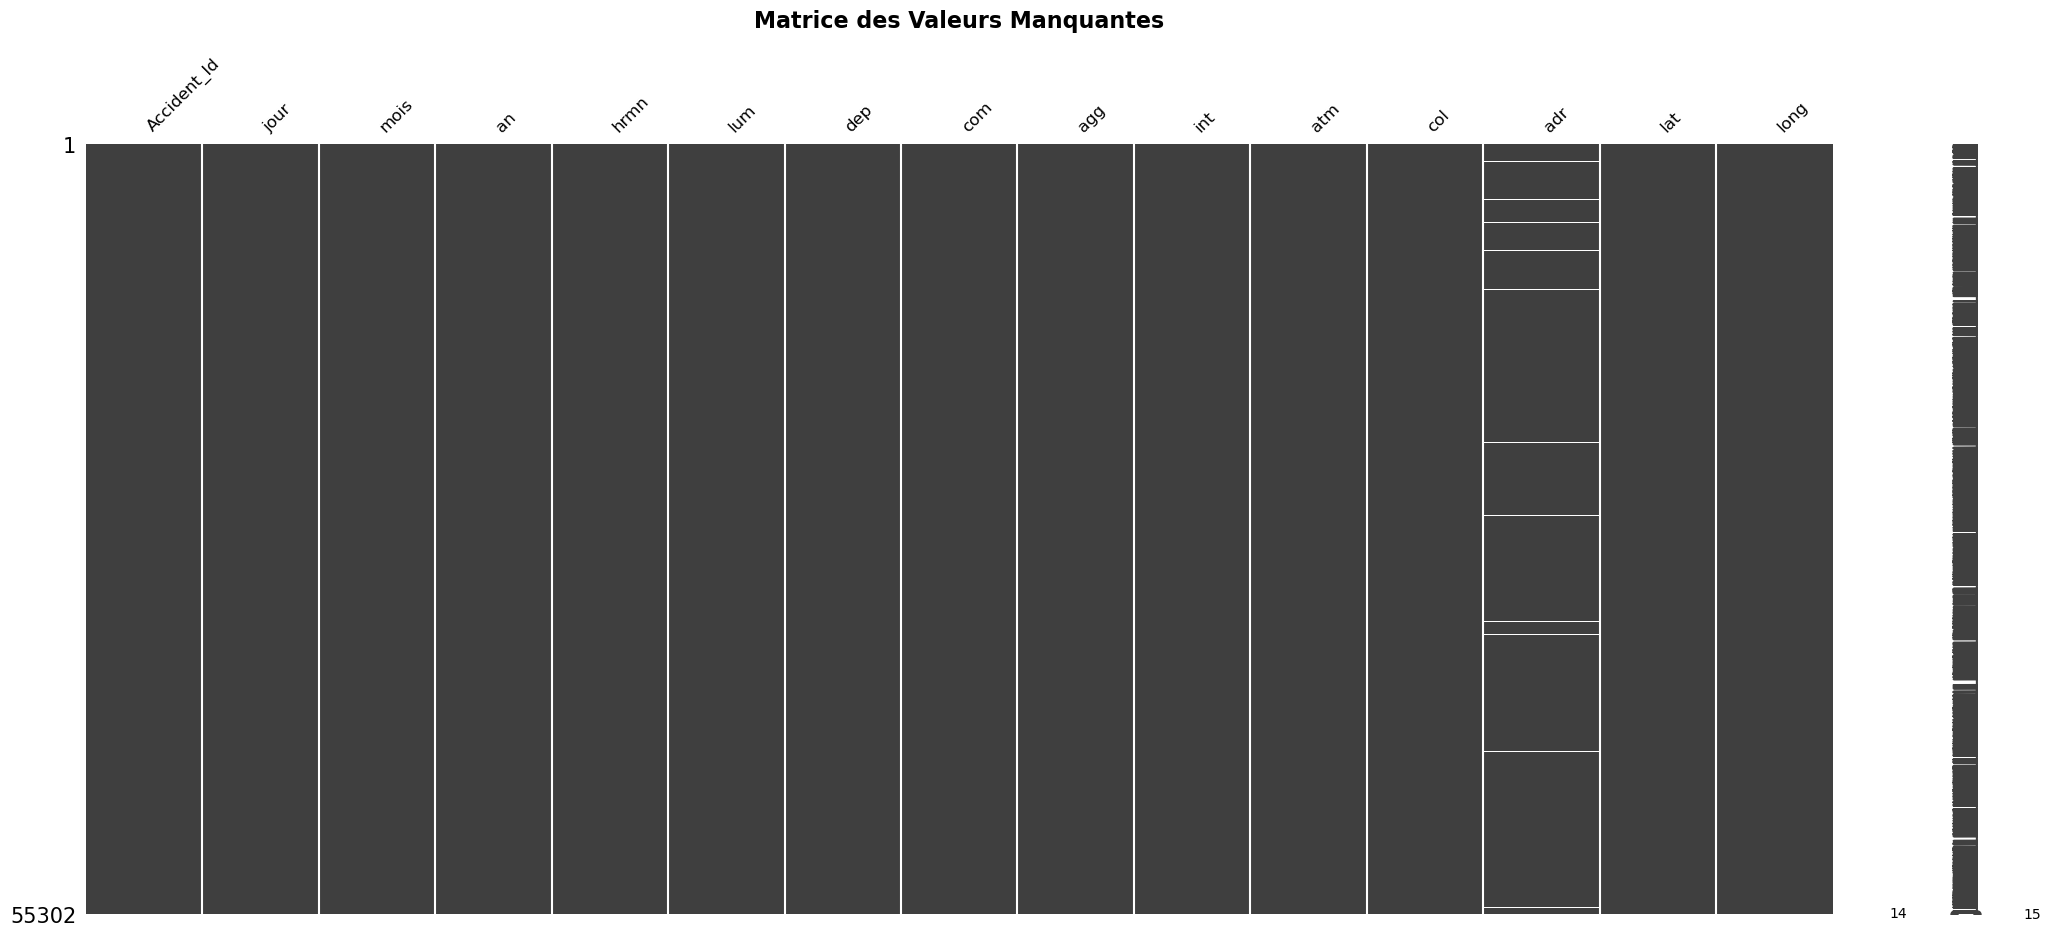

DATAFRAME : lieux-2022


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

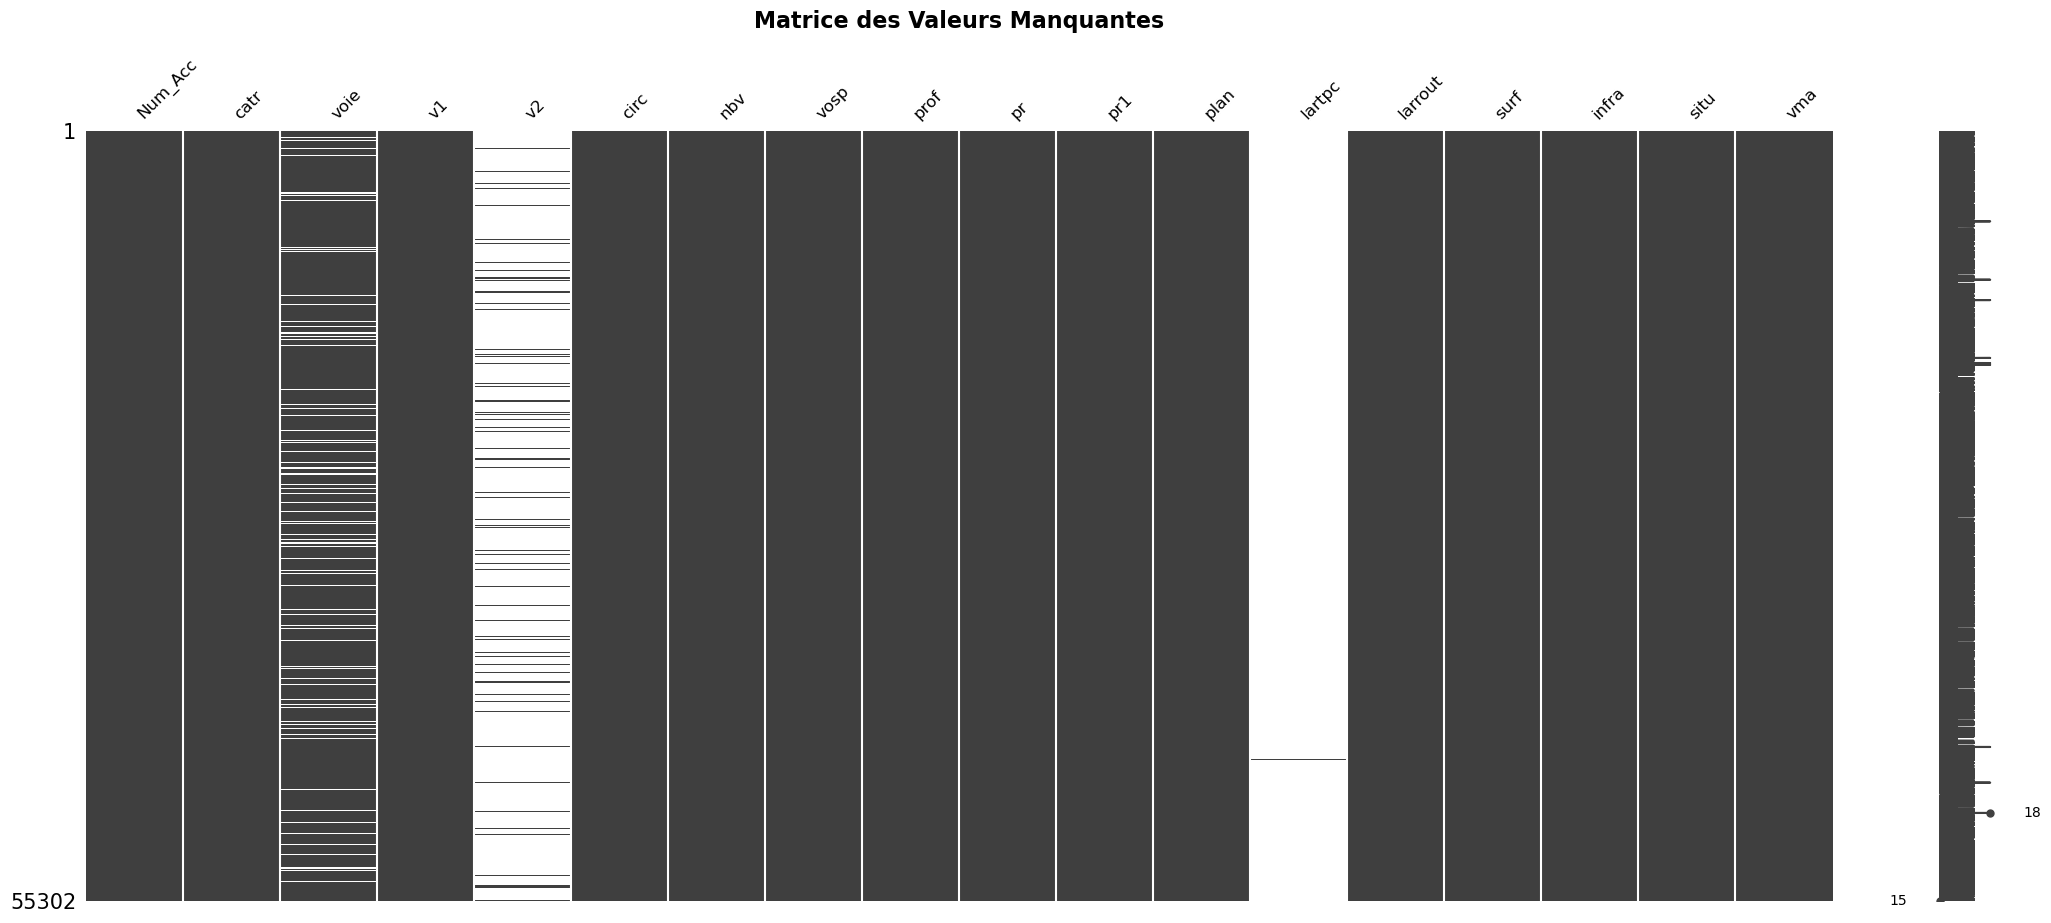

DATAFRAME : usagers-2022


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

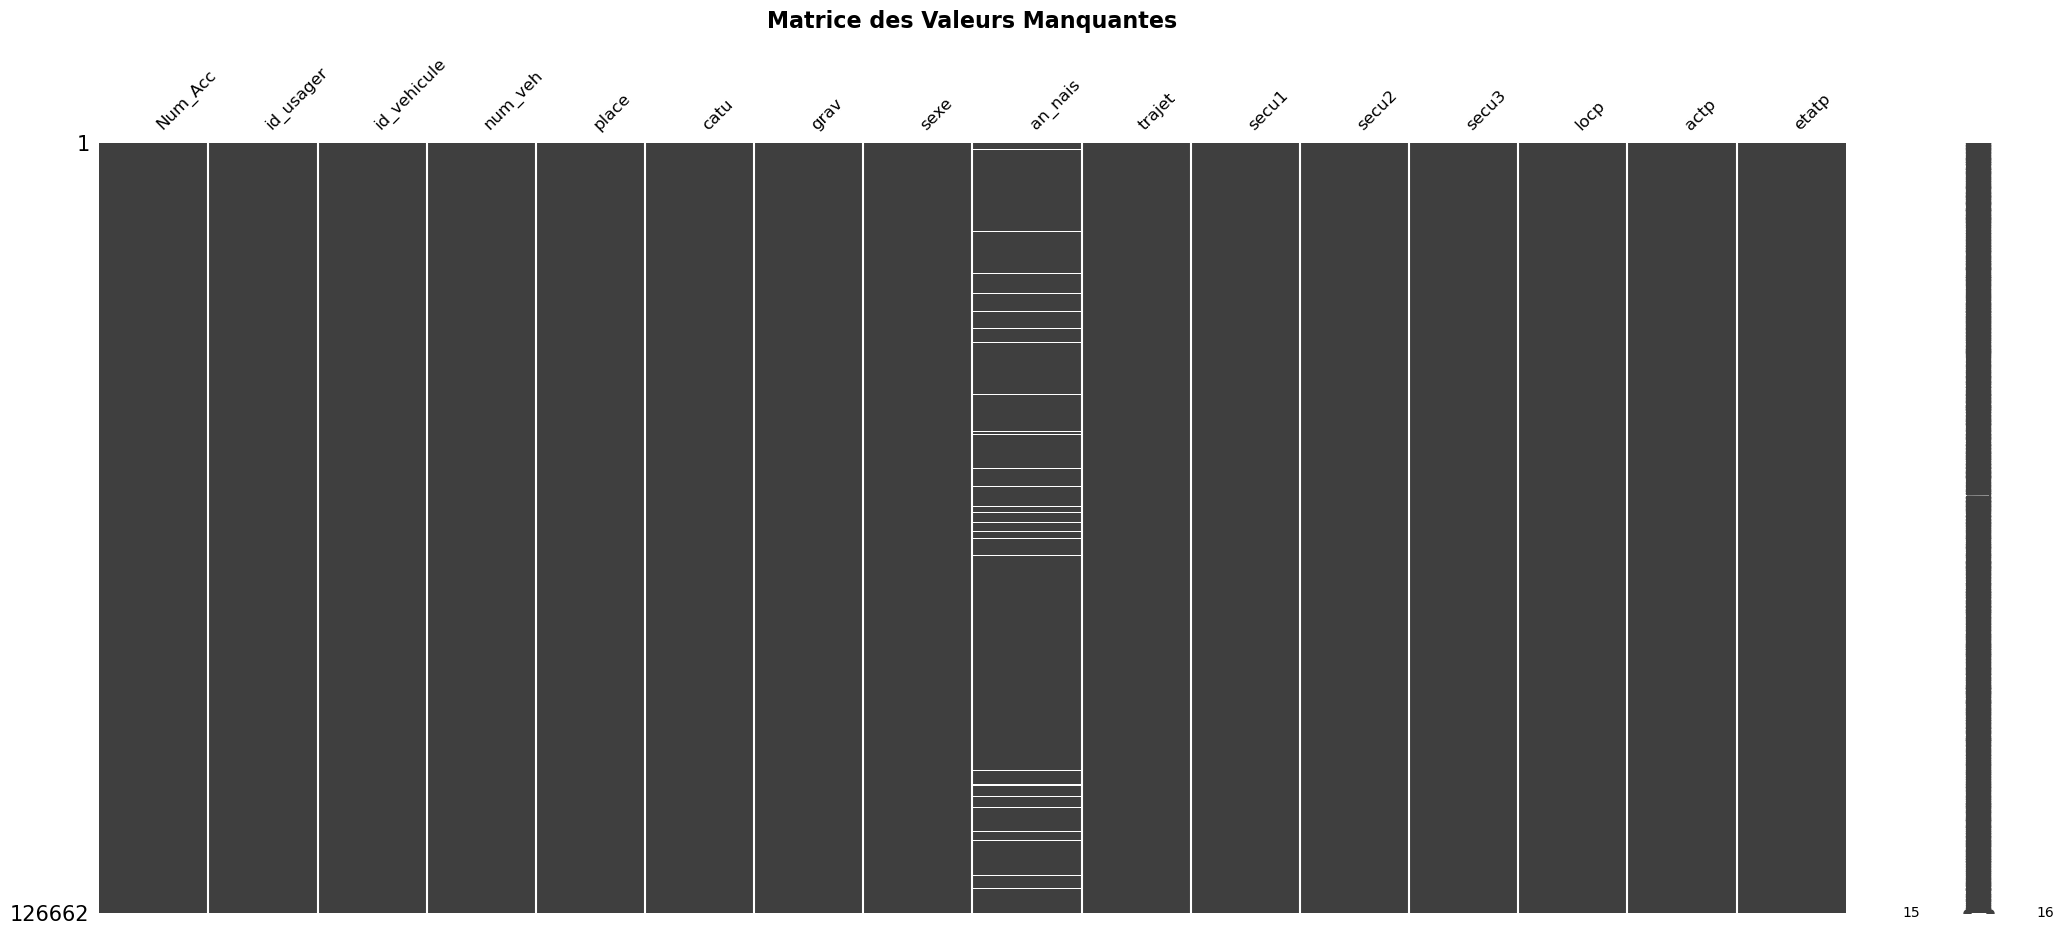

DATAFRAME : caract-2023


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

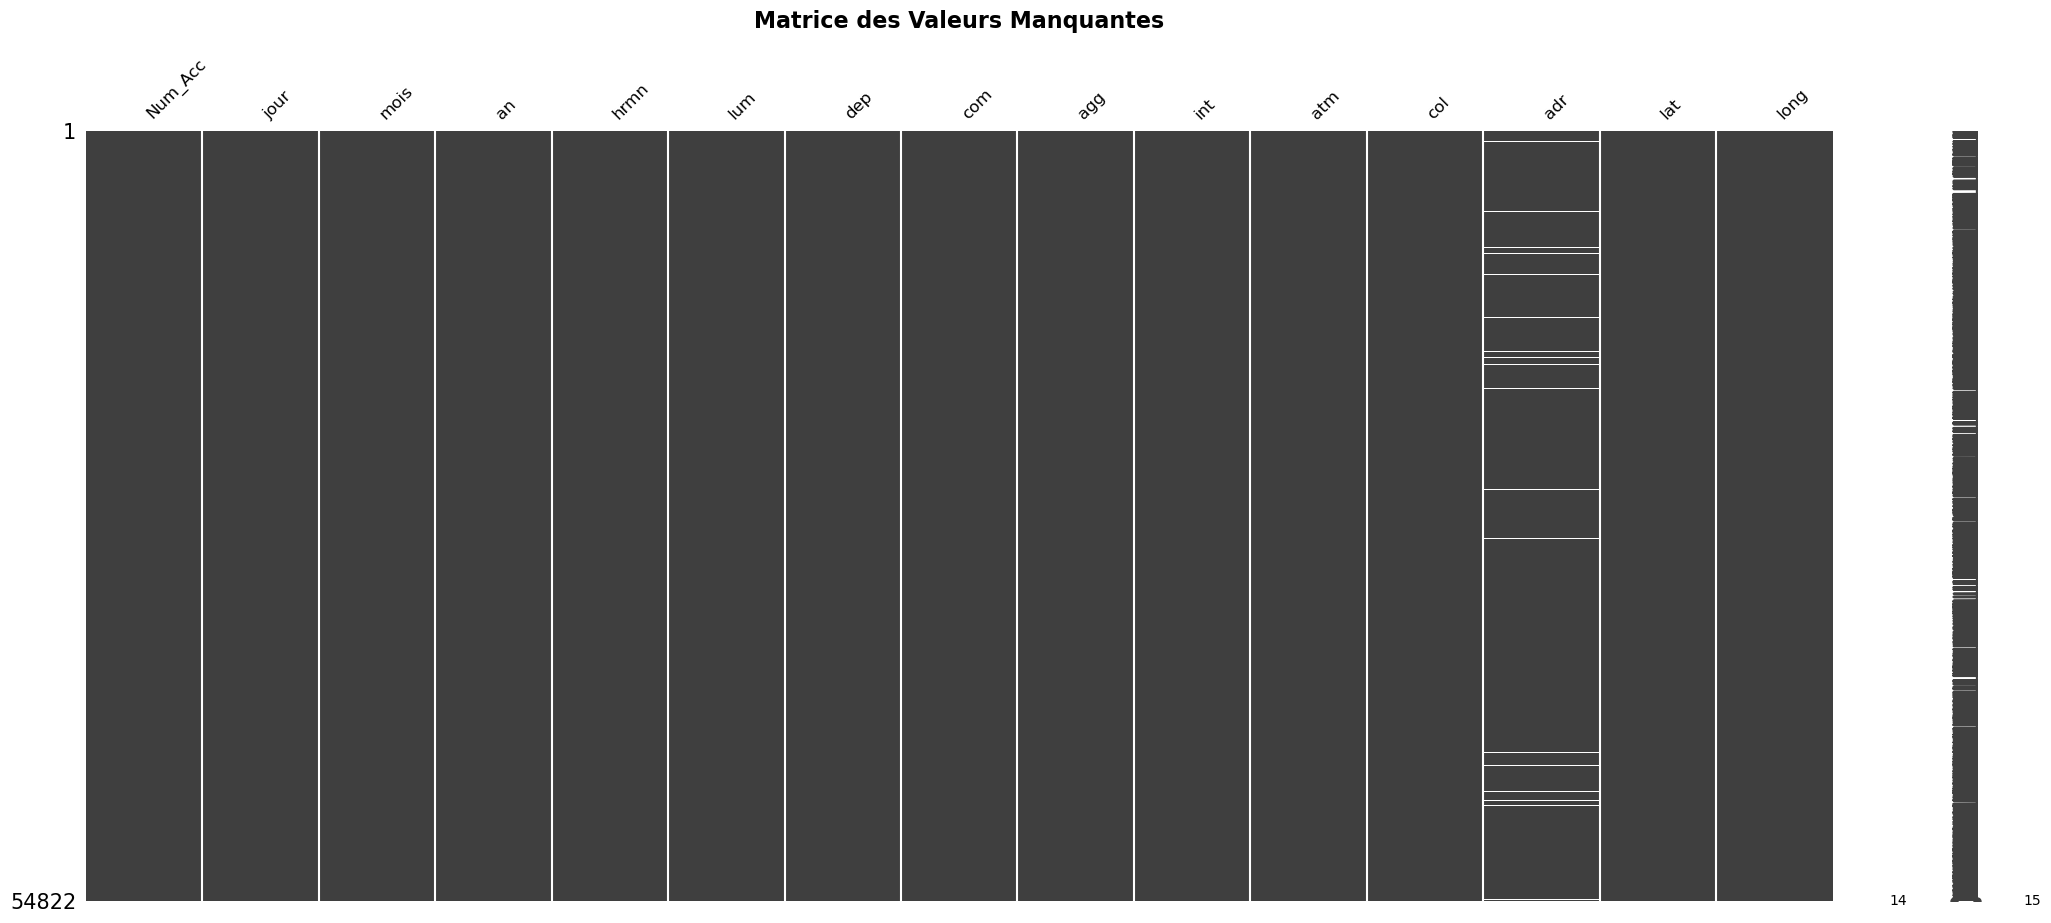

DATAFRAME : lieux-2023


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

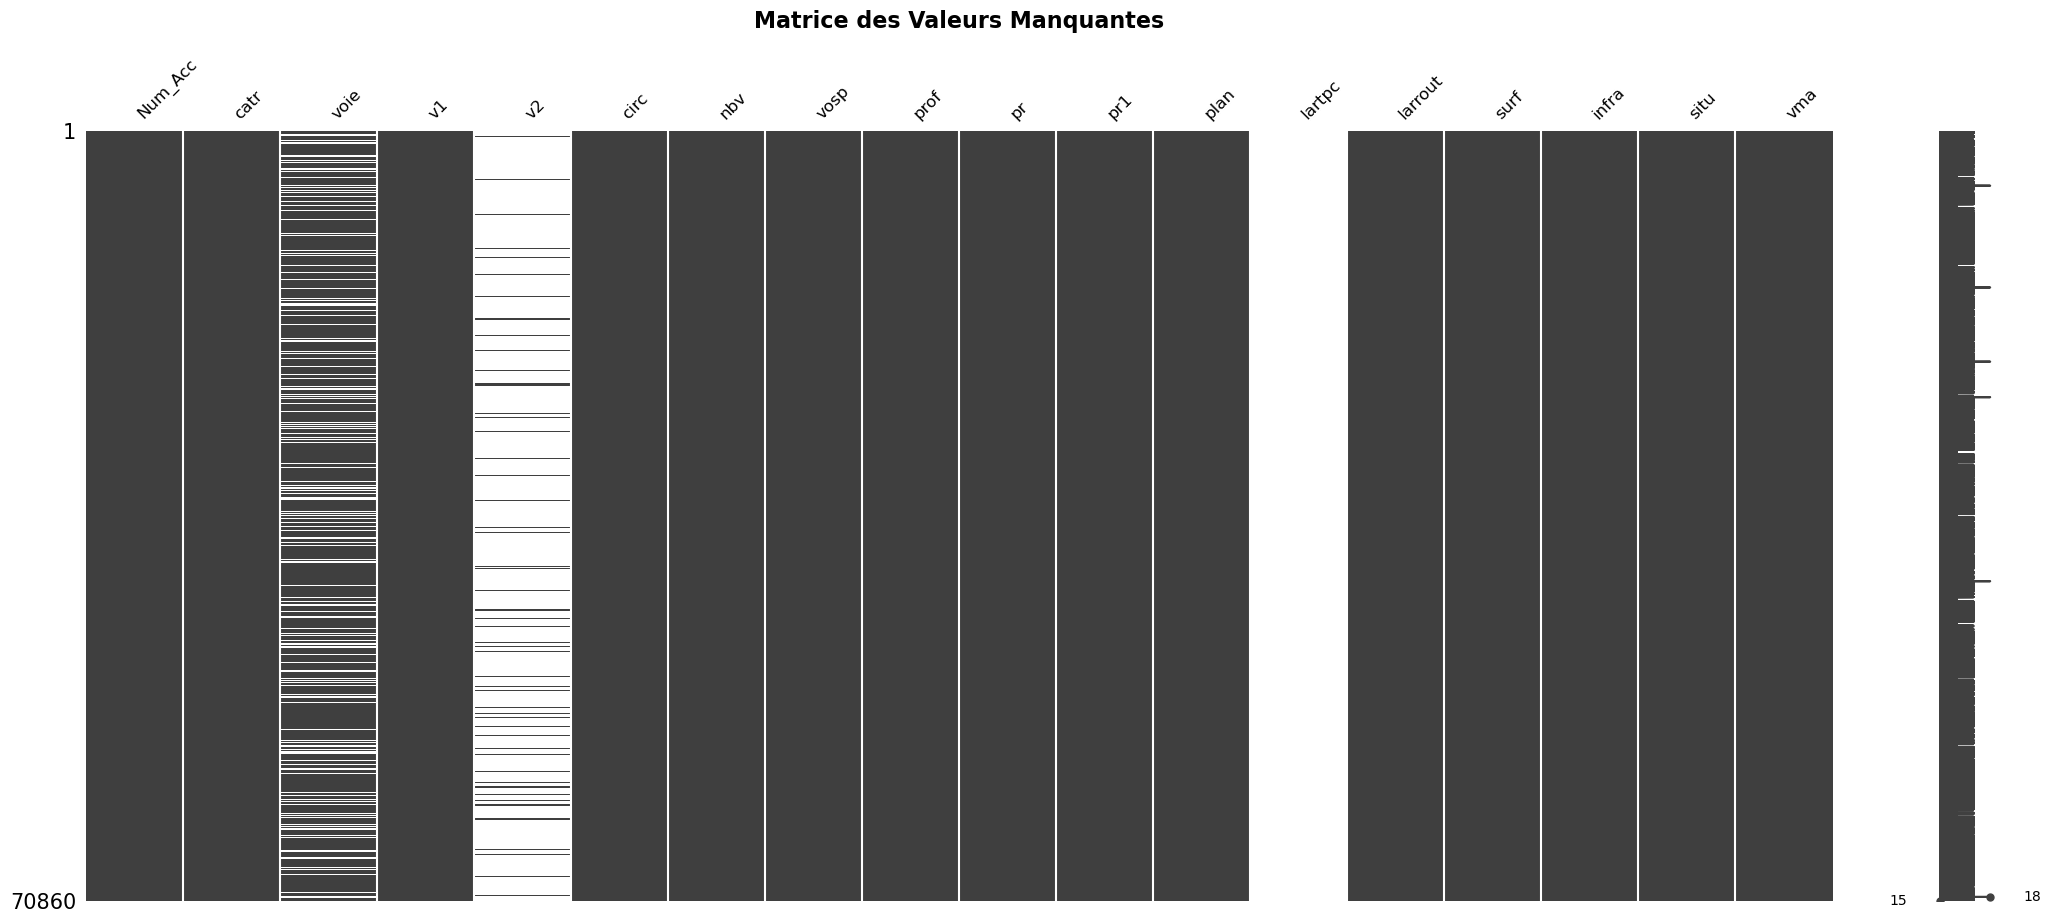

DATAFRAME : usagers-2023


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

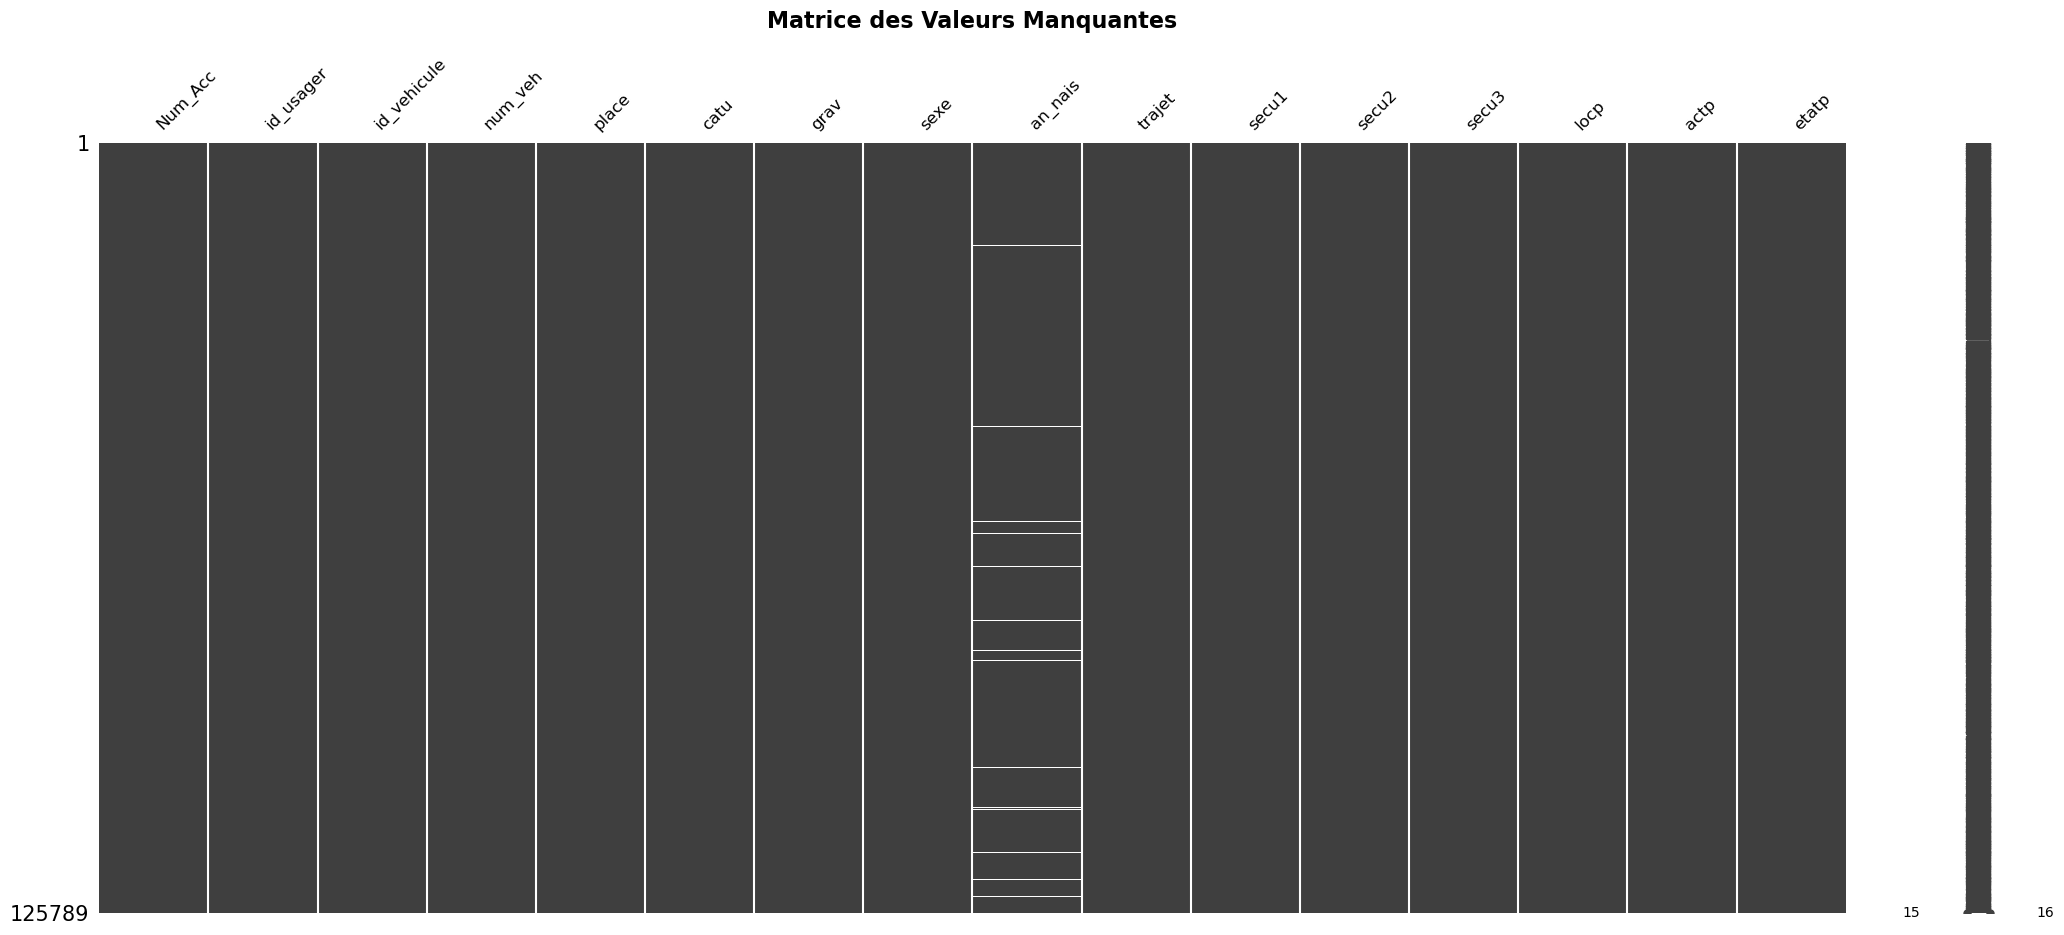

DATAFRAME : caract-2024


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

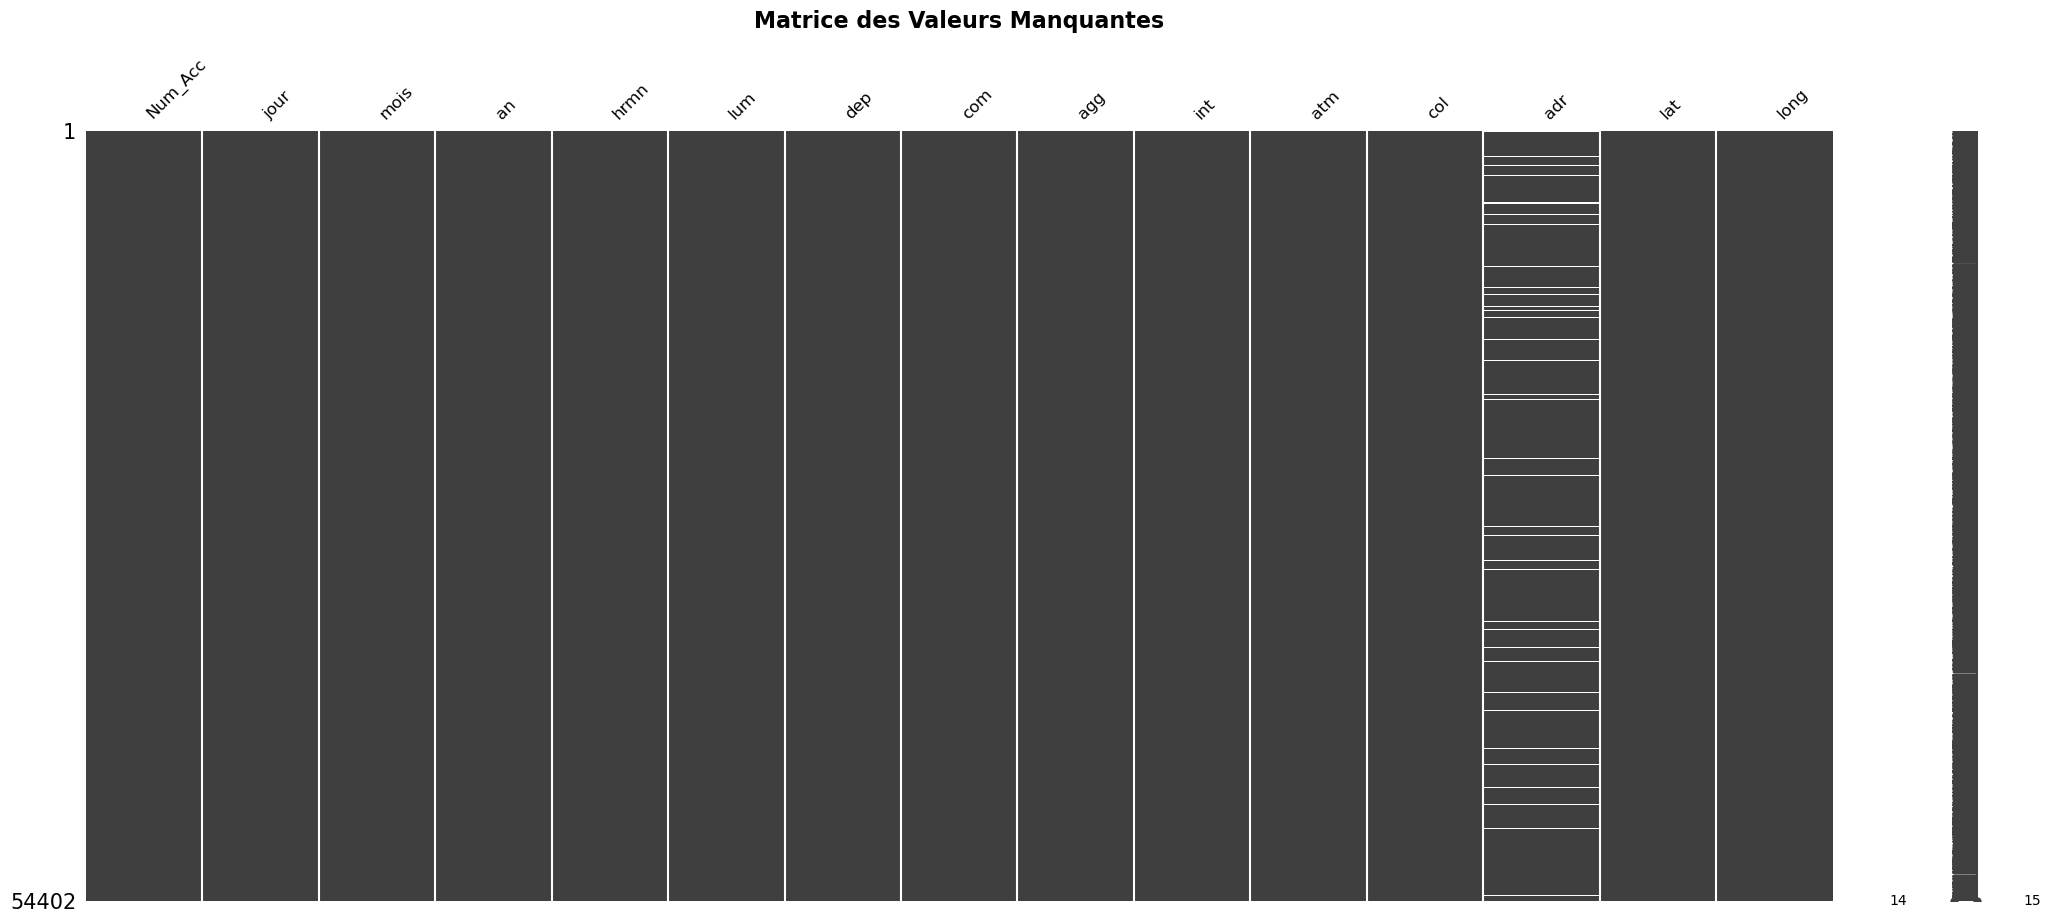

DATAFRAME : lieux-2024


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

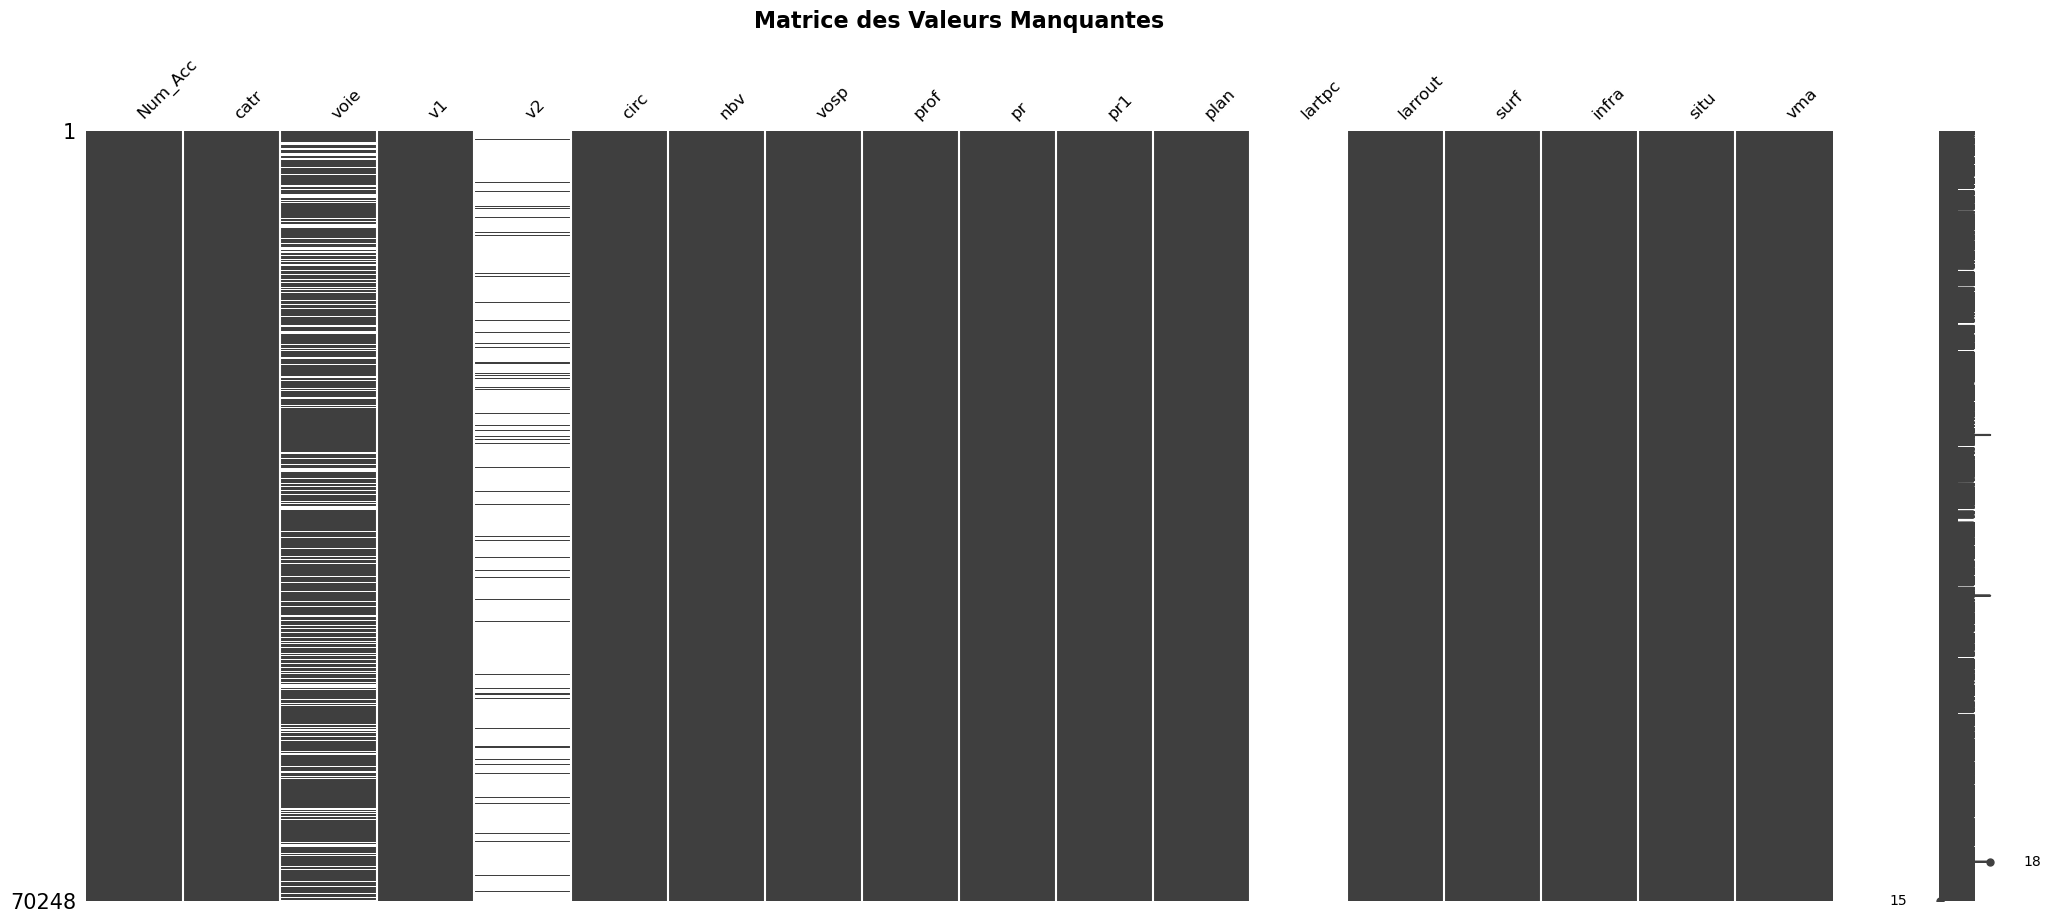

DATAFRAME : usagers-2024


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_7864\881298520.py:7: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1400x800 with 0 Axes>

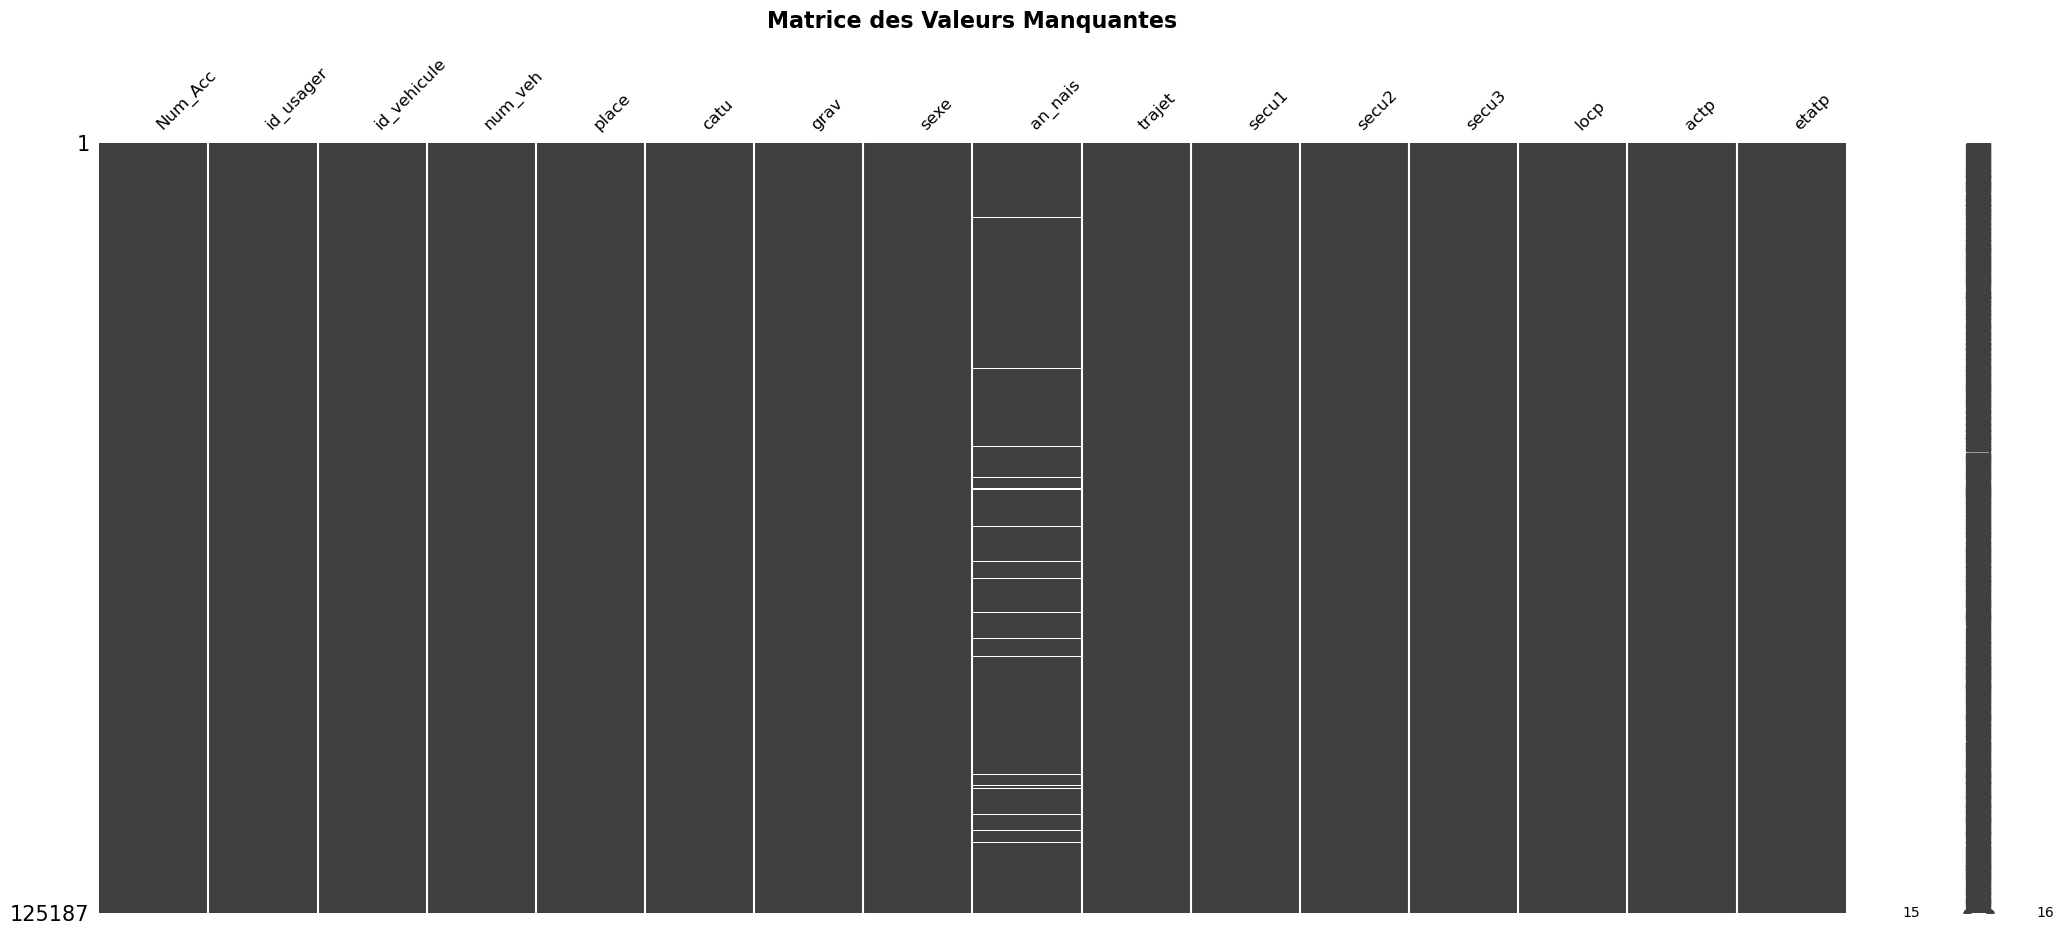

In [4]:
for name, df in dataframes.items():
	print("=" * 80)
	print(f"DATAFRAME : {name}")
	plt.figure(figsize=(14, 8))
	msno.matrix(df, fontsize=12, sparkline=True)
	plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
	plt.tight_layout()
	plt.show()

## Observations et premières conclusions

### 1. Présentation générale des données

Les données proviennent de la base BAAC (Bulletins d’Analyse des Accidents Corporels) et sont organisées en trois tables principales, disponibles pour les années 2022, 2023 et 2024 :

- **CARACTERISTIQUES** : informations générales sur l’accident
- **LIEUX** : caractéristiques de l’infrastructure et de la voie
- **USAGERS** : informations individuelles sur les personnes impliquées

Les tables sont reliées entre elles via un identifiant commun d’accident (`Num_Acc`).

### 2. Unité d’observation

- **CARACTERISTIQUES**  
  - 1 ligne = 1 accident  
  - L’identifiant `Num_Acc` est unique par ligne  
  - Environ 55 000 accidents par an, volume stable sur les trois années

Ce qu’il décrit principalement :
- date
- heure
- conditions atmosphériques
- luminosité
- type d’accident
- localisation administrative

Ces informations sont communes à tout l’accident.

- **USAGERS**  
  - 1 ligne = 1 personne impliquée dans un accident  
  - Plusieurs lignes peuvent correspondre à un même accident  
  - Le nombre de lignes est logiquement supérieur à celui de CARACTERISTIQUES

Ce qu’il décrit :
- une personne
- son rôle (conducteur, passager, piéton…)
- son âge, sexe
- sa gravité

- **LIEUX**  
  - 1 ligne correspond à une description de l’infrastructure associée à un accident  
  - Le nombre de lignes est parfois supérieur à celui de CARACTERISTIQUES, indiquant qu’un accident peut être associé à plusieurs descriptions de lieu ou de voie

Ce qu’il décrit :
- type de route
- intersection
- géométrie
- parfois coordonnées GPS

**Quelle est l’unité d’observation ?** 1 ligne = 1 accident ? 1 ligne = 1 personne ? Est-ce qu’il peut y avoir plusieurs lignes pour un même accident ?

Pour nos données, on suppose que :

| Fichier                   | 1 ligne =            |
| ------------------------- | -------------------- |
| Caractéristiques          | 1 accident           |
| Lieux                     | 1 accident           |
| Usagers                   | 1 personne impliquée |

Est-ce qu’il peut y avoir plusieurs lignes pour un même accident ? 
- Dans `Usagers` : oui
- Dans Caract et Lieux : non

### 3. Structure et types de données

- Toutes les variables sont importées en type `object` (string), choix volontaire pour la phase de découverte
- En réalité, les données contiennent plusieurs familles de variables :
  - Identifiants techniques (`Num_Acc`, identifiants usager / véhicule)
  - Variables temporelles (jour, mois, année, heure)
  - Variables géographiques (département, commune, latitude, longitude)
  - Variables catégorielles codées (conditions lumineuses, atmosphériques, collision, gravité, etc.)
- Les types actuels ne reflètent donc pas encore la nature réelle des variables

### 4. Valeurs manquantes

#### Table `CARACTERISTIQUES`

- La variable `adr` (adresse) présente :
  - environ 2 % de valeurs manquantes en 2022–2023
  - environ 4 % en 2024
- D’après la documentation, l’adresse est surtout renseignée en agglomération
- L’absence de `adr` ne doit donc pas être interprétée automatiquement comme une donnée manquante classique, mais comme une information non renseignée dans certains contextes

#### Table `LIEUX`

- `lartpc` : environ 99,9 % de valeurs manquantes  
- `v2` : environ 90 % de valeurs manquantes  
-> Ces variables sont très peu exploitables en l’état et apportent peu d’information potentielle

- `voie` : ~18 % de valeurs manquantes en 2023–2024  
  - L’absence de cette information limite certaines analyses, mais la présence de coordonnées GPS permet malgré tout une localisation spatiale

#### Table `USAGERS`

- `an_nais` (année de naissance) : environ 2 % de valeurs manquantes, taux stable sur les trois années
- Cela suggère un phénomène structurel et non un problème ponctuel de collecte

### 5. Identifiants et cohérence inter-années

- La clé de jointure principale entre les tables est `Num_Acc`
- Une incohérence de nommage a été identifiée en 2022 (`Accident_Id` au lieu de `Num_Acc`)
- Les volumes et structures sont globalement cohérents entre les années, ce qui facilite une future concaténation après harmonisation

### 6. Variable cible potentielle

- La variable de gravité (`grav`) se trouve dans la table `USAGERS`
- Elle est définie au niveau de la personne impliquée, et non au niveau de l’accident
- Il s’agit d’une variable catégorielle ordinale codée

Conséquence importante :
- La modélisation devra soit être réalisée au niveau usager,
- soit nécessiter une agrégation de la gravité au niveau accident

### 7. Variables temporelles et spatiales

- Les informations de date et d’heure sont éclatées sur plusieurs colonnes
- Aucune variable `datetime` n’est directement disponible
- Les coordonnées GPS (`lat`, `long`) sont présentes pour toutes les années, mais stockées en chaînes de caractères (avec séparateur décimal à vérifier)

### 8. Redondance et bruit potentiel

- Certaines informations sont partiellement redondantes (adresse, voie, coordonnées GPS)
- Plusieurs variables très peu renseignées introduisent du bruit
- De nombreuses variables sont codées et nécessitent une interprétation via la documentation officielle

### 9. To-do list globale pour le nettoyage

#### Harmonisation et structure
- [ ] Harmoniser le nom de la clé accident (`Accident_Id` → `Num_Acc` pour 2022)
- [ ] Vérifier l’unicité de `Num_Acc` dans `CARACTERISTIQUES`
- [ ] Vérifier le nombre de lignes par accident dans `LIEUX` et `USAGERS`

#### Types de données
- [ ] Convertir les variables numériques stockées en `object`
- [ ] Convertir `lat` et `long` en `float` (gestion du séparateur décimal)
- [ ] Construire une variable `datetime` à partir des colonnes de date et d’heure

#### Valeurs manquantes
- [ ] Définir une stratégie spécifique pour `adr` (ne pas imputer automatiquement)
- [ ] Supprimer ou ignorer les variables avec plus de 90 % de valeurs manquantes (`lartpc`, `v2`)
- [ ] Définir une stratégie cohérente pour `an_nais`

#### Variables catégorielles
- [ ] Identifier les variables codées à interpréter via la documentation
- [ ] Renommer les variables peu explicites pour améliorer la lisibilité
- [ ] Vérifier la cohérence des modalités entre années

#### Préparation à la modélisation
- [ ] Choisir le niveau d’analyse (usager vs accident)
- [ ] Définir une éventuelle stratégie d’agrégation au niveau accident
- [ ] Identifier les variables non disponibles au moment de l’accident et à exclure du modèle